In [1]:
import numpy as np
import cartopy.crs as ccrs
import easygems.healpix as egh
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import intake
mpl.rcParams['figure.dpi'] = 72

In [3]:
obs_file = "/pscratch/sd/w/wcmca1/hackathon/mcs/IMERGv7/stats/monthly/mcs_monthly_rainmap_hp8_20190801_20200831.nc"

ds = xr.open_dataset(obs_file)
ds

<xarray.Dataset> Size: 179MB
Dimensions:                  (time: 13, cell: 786432)
Coordinates:
  * time                     (time) datetime64[ns] 104B 2019-08-01 ... 2020-0...
  * cell                     (cell) int32 3MB 0 1 2 3 ... 786429 786430 786431
    lat                      (cell) float64 6MB ...
    lon                      (cell) float64 6MB ...
    crs                      int64 8B ...
Data variables:
    precipitation            (time, cell) float32 41MB ...
    mcs_precipitation        (time, cell) float32 41MB ...
    mcs_precipitation_count  (time, cell) float32 41MB ...
    mcs_cloud_count          (time, cell) float32 41MB ...
    ntimes                   (time) float32 52B ...
Attributes:
    Title:                    Monthly MCS precipitation statistics
    contact:                  Zhe Feng, zhe.feng@pnnl.gov
    created_on:               Thu Oct  9 11:58:41 2025
    grid_type:                HEALPix
    zoom_level:               8
    time_interval:            1.0
    precipitation_threshold:  2.0

<Figure size 460.8x345.6 with 0 Axes>

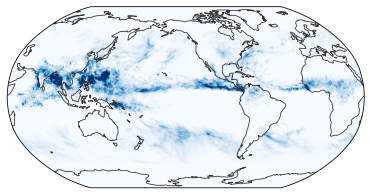

In [7]:
egh.healpix_show(ds['mcs_precipitation'].isel(time=0), cmap='Blues', vmin=0, vmax=500)

<Figure size 460.8x345.6 with 0 Axes>

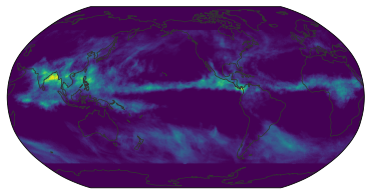

In [9]:
egh.healpix_show(ds['mcs_cloud_count'].isel(time=-1))

<Figure size 460.8x345.6 with 0 Axes>

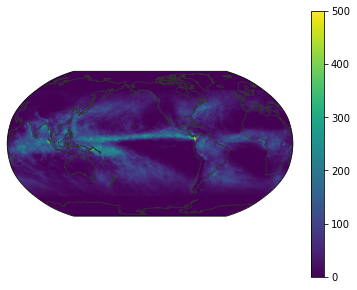

In [12]:
mcs_avg = ds['mcs_precipitation'].mean(dim='time')
im = egh.healpix_show(mcs_avg, vmin=0, vmax=500)
plt.colorbar(im)

<Figure size 460.8x345.6 with 0 Axes>

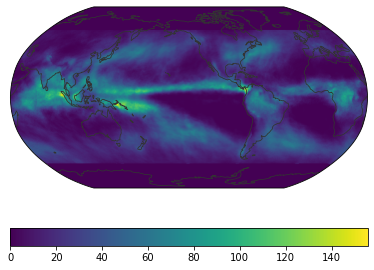

In [13]:
mcs_cloud_count_avg = ds['mcs_cloud_count'].mean(dim='time')
im = egh.healpix_show(mcs_cloud_count_avg)
plt.colorbar(im, orientation='horizontal')